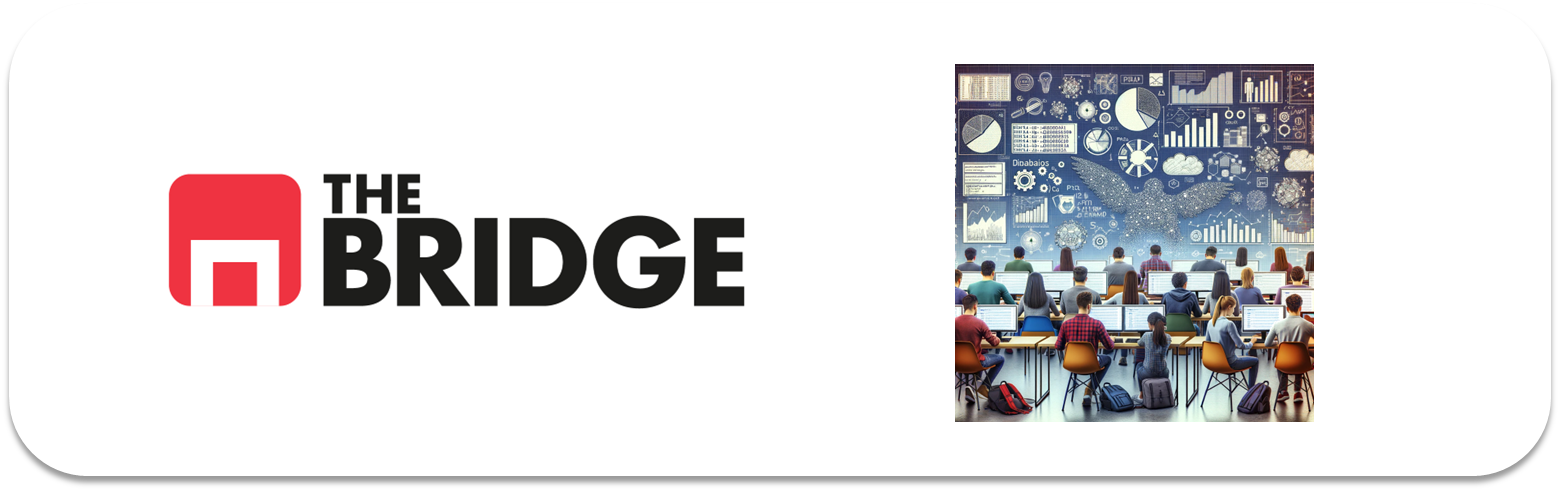

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



## 1. Carga del dataset

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import os

def buscar_csv(nombre="obligatoria_hard.csv", niveles_arriba=4):

    candidatas = [
        f"./data/hard_to_find/{nombre}",
        f"data/hard_to_find/{nombre}",
        f"./{nombre}",
        nombre,
    ]
    for ruta in candidatas:
        if os.path.exists(ruta):
            return ruta

    for raiz, _, ficheros in os.walk("."):
        if nombre in ficheros:
            return os.path.join(raiz, nombre)


    directorio = os.getcwd()
    for _ in range(niveles_arriba):
        directorio = os.path.dirname(directorio)
        for raiz, _, ficheros in os.walk(directorio):
            if nombre in ficheros:
                return os.path.join(raiz, nombre)

    return None

ruta_encontrada = buscar_csv()

if ruta_encontrada is None:
    raise FileNotFoundError(
        "No se ha encontrado 'obligatoria_hard.csv'. Revisa con os.getcwd() y "
        "os.listdir('.') dónde se está ejecutando el notebook, y coloca el csv "
        "en una carpeta 'data/hard_to_find' junto a él."
    )

print("Cargando dataset desde:", ruta_encontrada)
df = pd.read_csv(ruta_encontrada, sep="|")
df.shape

Cargando dataset desde: ./data/hard_to_find/obligatoria_hard.csv


(506, 13)

In [5]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [8]:
print("Nulos por columna:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())

Nulos por columna: 0
Filas duplicadas: 0


## 2. Elección y análisis de la variable target

El dataset es la versión clásica de Boston Housing. La variable natural para plantear
un problema de regresión es MEDV, ya que es una variable continua que queremos predecir 
a partir del resto de características de cada zona.

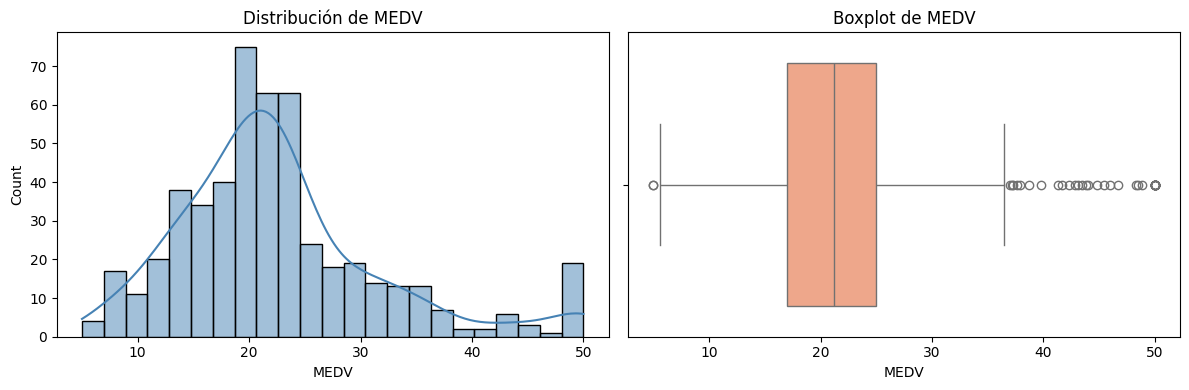

Skew de MEDV: 1.108


In [9]:
target = "MEDV"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[target], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de MEDV")
sns.boxplot(x=df[target], ax=axes[1], color="lightsalmon")
axes[1].set_title("Boxplot de MEDV")
plt.tight_layout()
plt.show()

print("Skew de MEDV:", df[target].skew().round(3))


La variable **MEDV** tiene una distribución razonablemente continua y unimodal, con una
ligera asimetría positiva y un grupo de valores "tope" en 50 (probablemente censurados en el
dataset original). Aun así, es perfectamente abordable con un modelo de regresión lineal: no
es una variable categórica ni binaria, y su rango y varianza permiten calcular errores
(MAE/RMSE) con sentido.

## 3. Split train / test

Split aleatorio simple del 75/25, con semilla para que  sea reproducible.

In [10]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.25, random_state=7)
print("Train:", train_set.shape, " Test:", test_set.shape)

Train: (379, 13)  Test: (127, 13)


## 4. Construcción de las parejas X, y (versión inicial, con todas las columnas)

In [11]:
X_train_full = train_set.drop(columns=[target])
y_train = train_set[target].copy()

X_test_full = test_set.drop(columns=[target])
y_test = test_set[target].copy()

X_train_full.shape, X_test_full.shape

((379, 12), (127, 12))

## 5. Mini-EDA y selección de features

In [12]:
corr_target = train_set.corr(numeric_only=True)[target].drop(target)
corr_target_abs = corr_target.abs().sort_values(ascending=False)
corr_target_abs

RM         0.750772
LSTAT      0.734750
PTRATIO    0.519943
INDUS      0.488393
TAX        0.481304
NOX        0.432739
CRIM       0.401279
RAD        0.394756
AGE        0.353937
ZN         0.350859
DIS        0.260882
CHAS       0.207917
Name: MEDV, dtype: float64

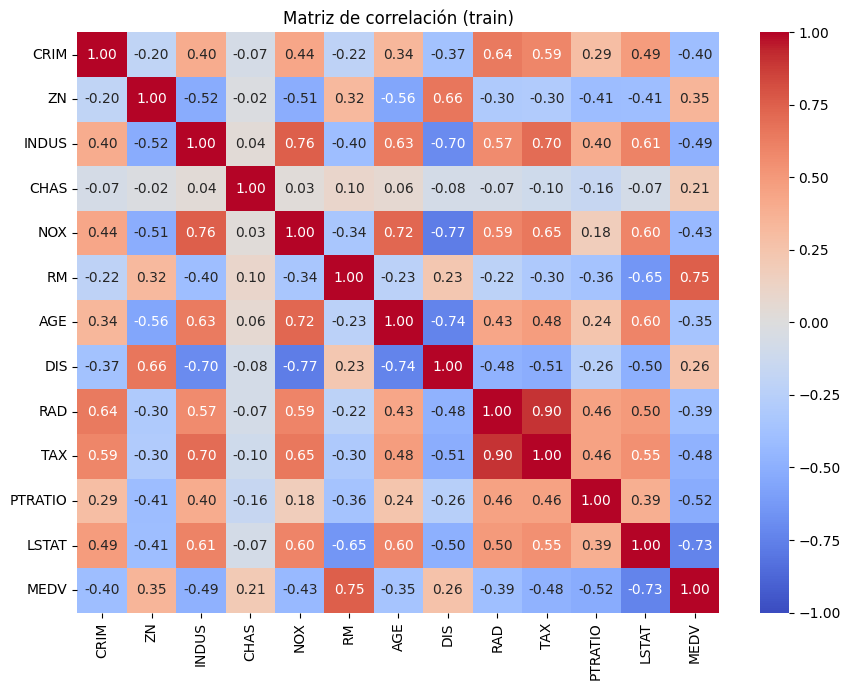

In [13]:
plt.figure(figsize=(9, 7))
sns.heatmap(train_set.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1)
plt.title("Matriz de correlación (train)")
plt.tight_layout()
plt.show()

In [14]:
UMBRAL_CORR = 0.35
candidatas = corr_target_abs[corr_target_abs > UMBRAL_CORR].index.tolist()
print("Candidatas por correlación con el target (|corr| > {}):".format(UMBRAL_CORR))
candidatas

Candidatas por correlación con el target (|corr| > 0.35):


['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'TAX', 'NOX', 'CRIM', 'RAD', 'AGE', 'ZN']

In [15]:
train_set["CHAS"].value_counts(), train_set["RAD"].value_counts()

(CHAS
 0.0    352
 1.0     27
 Name: count, dtype: int64,
 RAD
 5.0     95
 24.0    91
 4.0     82
 3.0     32
 1.0     18
 6.0     18
 2.0     17
 8.0     16
 7.0     10
 Name: count, dtype: int64)

`CHAS` es binaria (0/1), así que la tratamos como variable categórica. `RAD` es
numérica pero muy discreta y con una masa enorme de observaciones en el valor 24. 
En vez de descartarla o tratarla como continua, creamos una variable binaria 
`RAD_ALTO` que marca ese grupo dominante; así aprovechamos la señal sin meter una 
variable con una escala rara en el modelo lineal.

In [16]:
for split_name, split_df in [("train", train_set), ("test", test_set)]:
    split_df["RAD_ALTO"] = (split_df["RAD"] == 24).astype(int)

train_set[["RAD", "RAD_ALTO"]].drop_duplicates().sort_values("RAD")

,RAD,RAD_ALTO
193,1.0,0
96,2.0,0
41,3.0,0
205,4.0,0
264,5.0,0
111,6.0,0
244,7.0,0
62,8.0,0
397,24.0,1


In [17]:
features_num = [c for c in candidatas if c not in ("RAD",)]
features_cat = ["CHAS", "RAD_ALTO"]
print("Numéricas candidatas:", features_num)
print("Categóricas:", features_cat)


Numéricas candidatas: ['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'TAX', 'NOX', 'CRIM', 'AGE', 'ZN']
Categóricas: ['CHAS', 'RAD_ALTO']


In [18]:
def calcular_vif(dataframe, columnas):
    """VIF_i = 1 / (1 - R2_i), regresionando cada columna contra el resto (regresión lineal simple con sklearn)."""
    from sklearn.linear_model import LinearRegression
    vifs = {}
    for col in columnas:
        otras = [c for c in columnas if c != col]
        if not otras:
            vifs[col] = 1.0
            continue
        reg = LinearRegression()
        reg.fit(dataframe[otras], dataframe[col])
        r2 = reg.score(dataframe[otras], dataframe[col])
        vifs[col] = np.inf if r2 >= 1.0 else 1 / (1 - r2)
    return pd.Series(vifs).sort_values(ascending=False)

vif_actual = calcular_vif(train_set, features_num)
vif_actual


NOX        3.964056
INDUS      3.348835
LSTAT      3.271431
TAX        3.143002
AGE        2.841957
RM         2.056310
ZN         1.916318
PTRATIO    1.802419
CRIM       1.701175
dtype: float64

In [23]:
UMBRAL_VIF = 5.0
features_num_ok = features_num.copy()

# Eliminamos iterativamente la variable con mayor VIF mientras supere el umbral
while True:
    vif_actual = calcular_vif(train_set, features_num_ok)
    peor = vif_actual.index[0]
    if vif_actual.iloc[0] > UMBRAL_VIF and len(features_num_ok) > 1:
        print(f"Eliminamos '{peor}' por VIF = {vif_actual.iloc[0]:.2f}")
        features_num_ok.remove(peor)
    else:
        break

print("Features numéricas finales tras control de colinealidad:", features_num_ok)
calcular_vif(train_set, features_num_ok)

Features numéricas finales tras control de colinealidad: ['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'TAX', 'NOX', 'CRIM', 'AGE', 'ZN']


NOX        3.964056
INDUS      3.348835
LSTAT      3.271431
TAX        3.143002
AGE        2.841957
RM         2.056310
ZN         1.916318
PTRATIO    1.802419
CRIM       1.701175
dtype: float64

In [24]:
features_num = features_num_ok
features_num

['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'TAX', 'NOX', 'CRIM', 'AGE', 'ZN']

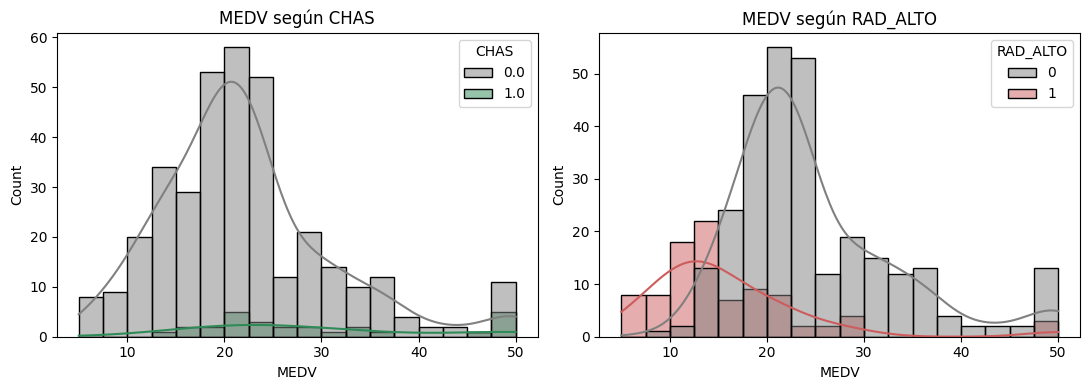

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(x=target, data=train_set, hue=train_set["CHAS"], kde=True, ax=axes[0], palette=["grey", "seagreen"])
axes[0].set_title("MEDV según CHAS")
sns.histplot(x=target, data=train_set, hue=train_set["RAD_ALTO"], kde=True, ax=axes[1], palette=["grey", "indianred"])
axes[1].set_title("MEDV según RAD_ALTO")
plt.tight_layout()
plt.show()

Como las dos variables categóricas aportan información, las mantenemos en el conjunto de features.

## 6. Tratamiento de variables

In [26]:
skew_vals = train_set[features_num].skew().sort_values(key=np.abs, ascending=False)
skew_vals

CRIM       5.433234
ZN         2.201622
LSTAT      0.936092
NOX        0.784682
PTRATIO   -0.777711
TAX        0.736399
AGE       -0.580489
RM         0.440756
INDUS      0.342542
dtype: float64

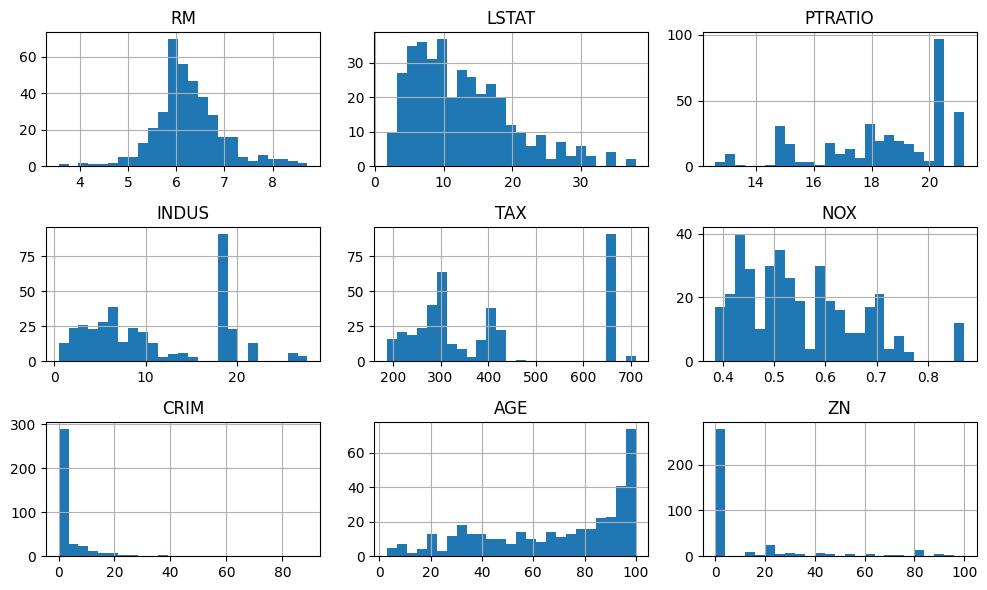

In [27]:
train_set[features_num].hist(figsize=(10, 6), bins=25)
plt.tight_layout()
plt.show()

Aplicamos log1p a: ['LSTAT', 'CRIM', 'ZN']


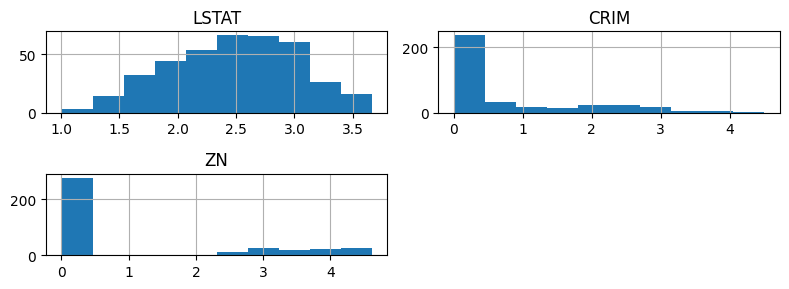

In [28]:
FEATURES_A_TRANSFORMAR = [f for f in features_num if abs(skew_vals[f]) > 0.8]
print("Aplicamos log1p a:", FEATURES_A_TRANSFORMAR)

for split_df in (train_set, test_set):
    for feat in FEATURES_A_TRANSFORMAR:
        split_df[feat] = np.log1p(split_df[feat])

train_set[FEATURES_A_TRANSFORMAR].hist(figsize=(8, 3))
plt.tight_layout()
plt.show()

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_set[features_num] = scaler.fit_transform(train_set[features_num])
test_set[features_num] = scaler.transform(test_set[features_num])  # nunca fit sobre test

train_set[features_num].describe().T[["min", "max", "mean"]]


,min,max,mean
RM,0.0,1.0,0.524738
LSTAT,0.0,1.0,0.555285
PTRATIO,0.0,1.0,0.671535
INDUS,0.0,1.0,0.386734
TAX,0.0,1.0,0.407969
NOX,0.0,1.0,0.341030
CRIM,0.0,1.0,0.170732
AGE,0.0,1.0,0.675956
ZN,0.0,1.0,0.207915


In [30]:
features_all = features_num + features_cat
print("Set final de features:", features_all)

X_train = train_set[features_all]
y_train = train_set[target]

X_test = test_set[features_all]
y_test = test_set[target]

X_train.shape, X_test.shape

Set final de features: ['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'TAX', 'NOX', 'CRIM', 'AGE', 'ZN', 'CHAS', 'RAD_ALTO']


((379, 11), (127, 11))

## 7. Modelo de regresión lineal

In [31]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("Intercepto:", round(lin_reg.intercept_, 3))

Intercepto: 30.983


## 8. Análisis de los pesos del modelo

In [32]:
coefs = pd.Series(lin_reg.coef_, index=features_all).sort_values(key=np.abs, ascending=False)
coefs

LSTAT      -25.455031
RM          19.547796
PTRATIO     -7.958648
CRIM        -6.779244
RAD_ALTO     5.805303
TAX         -5.146553
AGE          4.561238
NOX         -2.677422
CHAS         2.596804
INDUS        1.820795
ZN          -1.574266
dtype: float64

C:\Users\HP\AppData\Local\Temp\ipykernel_25524\1632041414.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefs.values, y=coefs.index, palette="viridis")


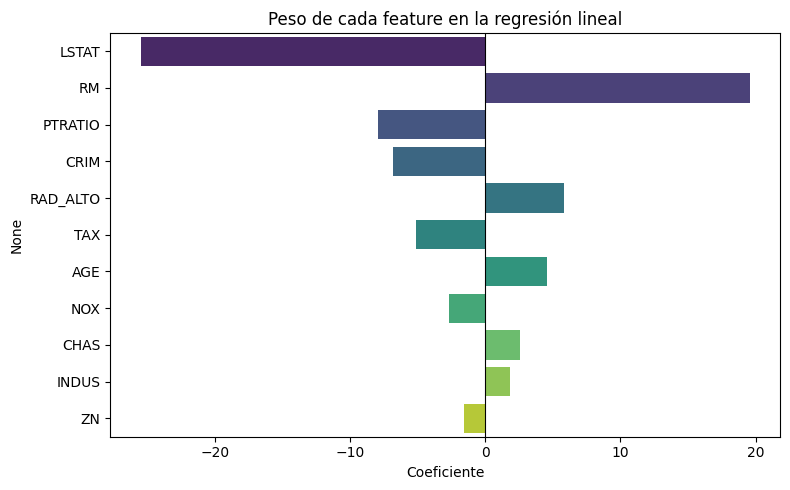

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(x=coefs.values, y=coefs.index, palette="viridis")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Peso de cada feature en la regresión lineal")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

Como las variables numéricas están escaladas con `MinMaxScaler` (0-1), los coeficientes son
directamente comparables entre sí en magnitud. `RM` (nº de habitaciones) y `LSTAT`
(% población de estatus bajo) son, con diferencia, las que más pesan sobre el precio: más
habitaciones sube el precio, más `LSTAT` lo baja.

## 9. Evaluación del modelo

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar(y_true, y_pred, etiqueta=""):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {etiqueta} ---")
    print(f"MAE : {mae:.3f}")
    print(f"MSE : {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2  : {r2:.3f}")
    print()
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

pred_train = lin_reg.predict(X_train)
pred_test = lin_reg.predict(X_test)

metrics_train = evaluar(y_train, pred_train, "Train")
metrics_test = evaluar(y_test, pred_test, "Test")

--- Train ---
MAE : 3.179
MSE : 18.963
RMSE: 4.355
R2  : 0.782

--- Test ---
MAE : 3.462
MSE : 25.984
RMSE: 5.097
R2  : 0.663



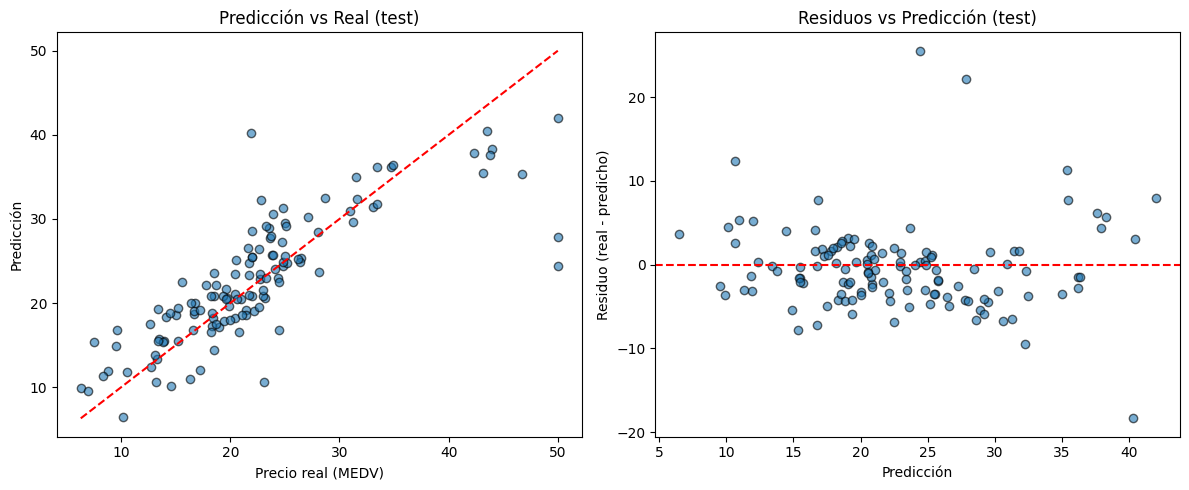

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, pred_test, alpha=0.6, edgecolor="k")
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
axes[0].plot(lims, lims, color="red", linestyle="--")
axes[0].set_xlabel("Precio real (MEDV)")
axes[0].set_ylabel("Predicción")
axes[0].set_title("Predicción vs Real (test)")

residuos = y_test - pred_test
axes[1].scatter(pred_test, residuos, alpha=0.6, edgecolor="k")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Residuo (real - predicho)")
axes[1].set_title("Residuos vs Predicción (test)")

plt.tight_layout()
plt.show()

El gráfico de predicción vs real muestra que la mayoría de puntos se agrupan cerca de la
diagonal, aunque el modelo tiende a **subestimar los precios más altos** (parte superior 
derecha), coherente con el tope/censura de la distribución de MEDV en torno a 50.
El gráfico de residuos no muestra un patrón marcado, aunque sí algo más de dispersión
para predicciones altas.

## 10. Regularización

In [38]:
from sklearn.linear_model import Ridge, Lasso

alphas = [0.1, 1.0, 10.0]
resultados = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    pred_tr = ridge.predict(X_train)
    pred_te = ridge.predict(X_test)
    resultados.append({
        "modelo": "Ridge", "alpha": alpha,
        "RMSE_train": np.sqrt(mean_squared_error(y_train, pred_tr)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, pred_te)),
        "R2_train": r2_score(y_train, pred_tr),
        "R2_test": r2_score(y_test, pred_te),
    })

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    pred_tr_l = lasso.predict(X_train)
    pred_te_l = lasso.predict(X_test)
    resultados.append({
        "modelo": "Lasso", "alpha": alpha,
        "RMSE_train": np.sqrt(mean_squared_error(y_train, pred_tr_l)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, pred_te_l)),
        "R2_train": r2_score(y_train, pred_tr_l),
        "R2_test": r2_score(y_test, pred_te_l),
    })

resultados_df = pd.DataFrame(resultados)
resultados_df

,modelo,alpha,RMSE_train,RMSE_test,R2_train,R2_test
0,Ridge,0.1,4.355057,5.095387,0.781610,0.663095
1,Lasso,0.1,4.564039,5.165534,0.760148,0.653755
2,Ridge,1.0,4.384049,5.095791,0.778693,0.663041
3,Lasso,1.0,7.313698,6.883694,0.384088,0.385111
4,Ridge,10.0,5.130309,5.530483,0.696938,0.603101
5,Lasso,10.0,9.319182,8.787063,0.000000,-0.001939


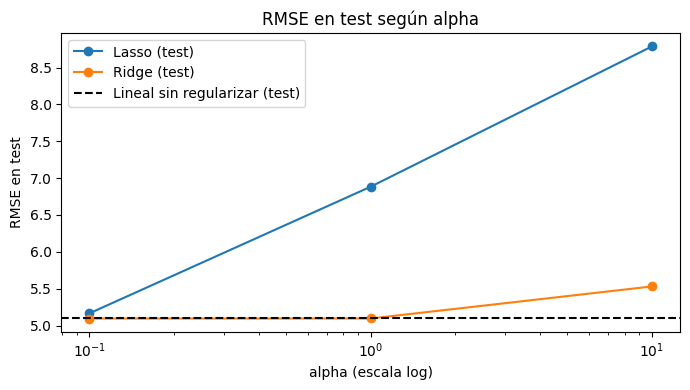

In [39]:
fig, ax = plt.subplots(figsize=(7, 4))
for modelo, grupo in resultados_df.groupby("modelo"):
    ax.plot(grupo["alpha"], grupo["RMSE_test"], marker="o", label=f"{modelo} (test)")
ax.axhline(metrics_test["RMSE"], color="black", linestyle="--", label="Lineal sin regularizar (test)")
ax.set_xscale("log")
ax.set_xlabel("alpha (escala log)")
ax.set_ylabel("RMSE en test")
ax.set_title("RMSE en test según alpha")
ax.legend()
plt.tight_layout()
plt.show()

In [40]:
mejor_fila = resultados_df.loc[resultados_df["RMSE_test"].idxmin()]
mejor_fila

modelo           Ridge
alpha              0.1
RMSE_train    4.355057
RMSE_test     5.095387
R2_train       0.78161
R2_test       0.663095
Name: 0, dtype: object

In [42]:
mejor_alpha_lasso = resultados_df[resultados_df.modelo == "Lasso"].sort_values("RMSE_test").iloc[0]["alpha"]
lasso_final = Lasso(alpha=mejor_alpha_lasso, max_iter=10000)
lasso_final.fit(X_train, y_train)
pd.Series(lasso_final.coef_, index=features_all).sort_values(key=np.abs, ascending=False)

LSTAT      -23.081856
RM          17.203247
PTRATIO     -5.283478
CHAS         2.121228
TAX         -1.352425
AGE          0.866740
INDUS       -0.000000
CRIM        -0.000000
NOX         -0.000000
ZN          -0.000000
RAD_ALTO    -0.000000
dtype: float64

## 11. Conclusiones

- El modelo de **regresión lineal** funciona bien: train y test dan métricas parecidas, así que generaliza correctamente y no hay sobreajuste relevante.
- La **regularización (Ridge/Lasso)** apenas mejora los resultados en este caso, porque el modelo base ya generalizaba bien.
- **Me quedo con Ridge** (alpha bajo): rinde igual que la regresión lineal simple pero con coeficientes más estables.
- Como mejora futura, se podrían probar modelos no lineales (árboles, ensembles) para capturar mejor relaciones como las de `LSTAT` y `RM` con el precio.